### Ordinary Differential Solution
$$
f'(x, y) = \frac{dy}{dx}
$$

##### Forward Euler's Method
$$
y_{n+1} \approx y_n + h \space f'(x_n, y_n)
$$

In [2]:
import numpy as np
# ic
def forward_euler(f, x0, y0, xn, n=10):
    xs, ys = [x0], [y0]
    dx = (xn - x0)/n
    
    for _ in range(n):
            xi, yi = xs[-1], ys[-1] # assign xi, yi as last point
            y = yi + dx * f(xi, yi)
            ys.append(y)
            xs.append(xi+dx)
    return xs, ys

def f(x, y):
        return 2 * x

xs, ys = forward_euler(f, 0, 0, 1.5, 100)
print(xs[-1], ys[-1])
print('error:', abs(ys[-1] - 1.5 ** 2))

1.4999999999999976 2.2274999999999996
error: 0.02250000000000041


##### Backward Euler Method
$$
y_{n+1} \approx y_n + h \space f(x_{n+1}, y_{n+1})
$$
we need to solve
$$
g(y)=y - y_n - h \space f(x_{n+1}, y)
$$
by applying newton-raphson
$$
y_{new} = y - \frac{g(y)}{g'(y)}
$$
where
$$
g'(y)=1-h \space \frac{\partial f}{\partial y}(x_{n+1}, y)
$$

In [3]:
def back_euler(f, dfdy, x0, y0, xn, n=10, tol=1e-7, max_iter=20):
    xs, ys = [x0], [y0]
    dx = (xn - x0)/n
    
    for _ in range(n):
        xi, yi = xs[-1], ys[-1]
        x = xi + dx             # x = x{i+1}
        y = yi + f(xi, yi) * dx

        # newton raphson
        for _ in range(max_iter):
            y_new = y - (y - yi - dx * f(x, y) ) / (1 - dx * dfdy(x, y))

            if abs(y_new - y)<tol:
                y = y_new
            else:
                y = y_new
                break
            
        # assign xi and yi for next step
        xs.append(x+dx), ys.append(y_new)
    return x, y

def f(x, y):
    return y**2 - 1
def dfdy(x, y): # part derv of f with y
    return 2 * y

print(forward_euler(f, 0, 0.5, 1, n=500))
print(back_euler   (f, dfdy, 0, 0.5, 1, n=100))        
    

([0, 0.002, 0.004, 0.006, 0.008, 0.01, 0.012, 0.014, 0.016, 0.018000000000000002, 0.020000000000000004, 0.022000000000000006, 0.024000000000000007, 0.02600000000000001, 0.02800000000000001, 0.030000000000000013, 0.032000000000000015, 0.034000000000000016, 0.03600000000000002, 0.03800000000000002, 0.04000000000000002, 0.04200000000000002, 0.044000000000000025, 0.04600000000000003, 0.04800000000000003, 0.05000000000000003, 0.05200000000000003, 0.054000000000000034, 0.056000000000000036, 0.05800000000000004, 0.06000000000000004, 0.06200000000000004, 0.06400000000000004, 0.06600000000000004, 0.06800000000000005, 0.07000000000000005, 0.07200000000000005, 0.07400000000000005, 0.07600000000000005, 0.07800000000000006, 0.08000000000000006, 0.08200000000000006, 0.08400000000000006, 0.08600000000000006, 0.08800000000000006, 0.09000000000000007, 0.09200000000000007, 0.09400000000000007, 0.09600000000000007, 0.09800000000000007, 0.10000000000000007, 0.10200000000000008, 0.10400000000000008, 0.1060

##### Midpoint Method
$$
y_{n+1} = y_n + h \space f'(x_{n+\frac{1}{2}}, y_{n+\frac{1}{2}})
$$
where
$$
y_{n+\frac{1}{2}} = y_n + \frac{h}{2} \space f'(x_n, y_n)

In [4]:
def midpoint(f, x0, y0, xn, n=10):
    xs, ys = [x0], [y0]
    dx = (xn - x0)/n

    for _ in range(n):
        xi, yi = xs[-1], ys[-1]
        y_mid = yi + dx/2 * f(xi, yi)
        y = yi + dx * f(xi+dx/2, y_mid)
        ys.append(y)
        xs.append(xi + dx)
    return xs, ys

xs, ys = midpoint(f, 0, 0.5, 1, 100)
print(xs[-1], ys[-1])

1.0000000000000007 -0.4224712586613194


##### Taylor 2nd order
$$
y_{n+1} = y_n + hf'(x_n) + \frac{h^2}{2} f''(x_n)
$$

In [5]:
import numpy as np
# ic
def taylor2nd(f1, f2, x0, y0, xn, n=10):
    xi, yi = x0, y0
    dx = (xn - x0)/n

    for _ in range(n):
        yi += dx * f1(xi, yi) + dx**2/2 * f2(xi, yi)
        xi += xi+dx
    return xi, yi

def f1(x, y):
    return y**2 - 1

def f2(x, y):
    return 2 * y
taylor2nd(f1, f2, 0, 0.5, 1, 100)

(1.2676506002282296e+28, -0.4215414787937986)

##### Runge-Kutta Order 2
Suppose
$$
y_{n+1} = y_n + h \space f'(x_n, y_n) + \frac{h^2}{2} \space f''(x_n, y_n) + O(h^3)
$$
Because
$$
f''(x, y)
= \frac{f'(x+h, y+hf)-f'(x, y)}{h}
$$
Plug in first equation
$$
\begin{aligned}
y_{n+1} 
&\approx y_n + h \space f'(x_n, y_n) + \frac{h^2}{2} \space \frac{f'(x_n+h, y_n+hf)-f'(x_n, y_n)}{h} \\
&= y_n + h \space f'(x_n, y_n) + \frac{h}{2} \space \Big[f'(x_n+h, y_n+hf)-f'(x_n, y_n)\Big] \\
&= y_n + \frac{h}{2} \space \Big[f'(x_n, y_n) + f'(x_n +h, y_n +hf') \Big] 
\end{aligned} 
$$
Thus,
$$
y_{n+1}= y_n + \frac{h}{2} \space (K_1 + K_2)
$$
where
$$\begin{aligned}
& K_1 = f'(x_n, y_n) \\
& K_2 = f'(x_n + h, y_n + hK_1)
\end{aligned}$$
The local error is $O(h^3)$ but the **Global Error** is given by \
$N \times O(h^3) = \frac{1}{h} \times O(h^3) = O(h^2) $



In [6]:
def rk2(f, x0, y0, xn, n):
    xs, ys = [x0], [y0]
    dx = (xn - x0)/n
    for _ in range(n):
        xi, yi = xs[-1], ys[-1]
        k1 = f(xi, yi)
        k2 = f(xi + dx, yi + dx * k1)
        y = yi + dx/2 * (k1 +k2)
        ys.append(y)
        xs.append(xi + dx)
        
    return xs, ys

def f(x, y):
    return y**2 + 1

xs, ys = rk2(f, 0, 0.5, 1, 100)
print(xs[-1], ys[-1])

1.0000000000000007 9.266362773055338


##### Runge-Kutta Order 4
From 4th order Taylor Expansion, we can finally yield
$$
y_{n+1} = y_n + \frac{h}{6} \space (K_1 + 2K_2 + 2K_3 + K_4)
$$
where \
$
K_1 = f'(x_n, y_n) \\
K_2 = f'(x_n + \frac{h}{2}, y_n + \frac{h}{2}K_1) \\
K_3 = f'(x_n + \frac{h}{2}, y_n + \frac{h}{2}K_2) \\
K_4 = f'(x_n + h, y_n + h K_3) \\
$\
with local error $O(h^5)$ but Global Error $O(h^4)$

In [7]:
def rk4(f, x0, y0, xn, n):
    xs, ys = [x0], [y0]
    dx = (xn-x0)/n
    for _ in range(n):
        xi, yi = xs[-1], ys[-1]
        k1 = f(xi, yi)
        k2 = f(xi + dx/2, yi + dx/2 * k1)
        k3 = f(xi + dx/2, yi + dx/2 * k2)
        k4 = f(xi + dx  , yi + dx   * k3)
        y = yi + dx/6 * (k1 + 2*k2 + 2*k3 + k4)
        ys.append(y), xs.append(xi + dx)
    return xs, ys
xs, ys = rk4(f, 0, 0.5, 1, 10)
print(xs[-1], ys[-1])

0.9999999999999999 9.247435699788827


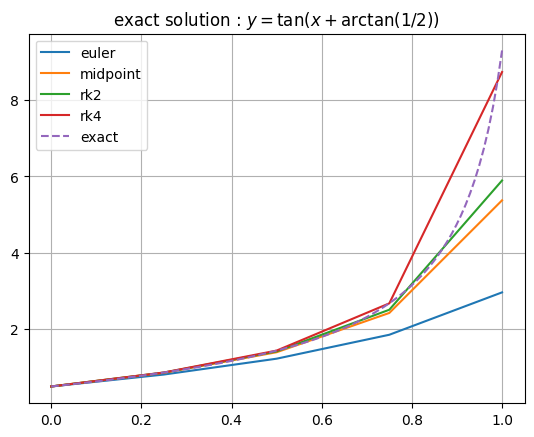

In [12]:
import matplotlib.pyplot as plt
import numpy as np
N = 4
def f(x, y):
    return y**2 + 1
xs1, ys1 = forward_euler(f, 0, 0.5, 1, N)
xs2, ys2 = midpoint(f, 0, 0.5, 1, N)
xs3, ys3 =      rk2(f, 0, 0.5, 1, N)
xs4, ys4 =      rk4(f, 0, 0.5, 1, N)
plt.plot(xs1, ys1, label='euler')
plt.plot(xs2, ys2, label='midpoint')
plt.plot(xs3, ys3, label='rk2')
plt.plot(xs4, ys4, label='rk4')
ax = np.linspace(0, 1, 100)
plt.plot(ax, np.tan(ax + np.arctan(0.5)), '--', label='exact')
plt.title(r"exact solution : $ y=\tan(x+\arctan(1/2)) $")
plt.legend()
plt.grid()
plt.figure
plt.show()